In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv", encoding='latin1')

descriptions = pd.read_csv(
    "product_descriptions.csv",
    encoding='latin1'
)

attributes = pd.read_csv(
    "attributes.csv",
    encoding='latin1'
)

In [3]:
train.head()

,id,product_uid,product_title,search_term,relevance
0,2,100001,Simpson Strong-Tie 12-Gauge Angle,angle bracket,3.00
1,3,100001,Simpson Strong-Tie 12-Gauge Angle,l bracket,2.50
2,9,100002,BEHR Premium Textured DeckOver 1-gal. #SC-141 ...,deck over,3.00
3,16,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,rain shower head,2.33
4,17,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,shower only faucet,2.67


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74067 entries, 0 to 74066
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             74067 non-null  int64  
 1   product_uid    74067 non-null  int64  
 2   product_title  74067 non-null  object 
 3   search_term    74067 non-null  object 
 4   relevance      74067 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.8+ MB


In [5]:
train.describe()

,id,product_uid,relevance
count,74067.000000,74067.000000,74067.000000
mean,112385.709223,142331.911553,2.381634
std,64016.573650,30770.774864,0.533984
min,2.000000,100001.000000,1.000000
25%,57163.500000,115128.500000,2.000000
50%,113228.000000,137334.000000,2.330000
75%,168275.500000,166883.500000,3.000000
max,221473.000000,206650.000000,3.000000


In [6]:
train.shape

(74067, 5)

In [7]:
train.columns

Index(['id', 'product_uid', 'product_title', 'search_term', 'relevance'], dtype='object')

In [8]:
train.isnull().sum()

id               0
product_uid      0
product_title    0
search_term      0
relevance        0
dtype: int64

In [9]:
descriptions.isnull().sum()

product_uid            0
product_description    0
dtype: int64

In [10]:
train = pd.merge(
    train,
    descriptions,
    on="product_uid",
    how="left"
)

In [11]:
train.head()

,id,product_uid,product_title,search_term,relevance,product_description
0,2,100001,Simpson Strong-Tie 12-Gauge Angle,angle bracket,3.00,"Not only do angles make joints stronger, they ..."
1,3,100001,Simpson Strong-Tie 12-Gauge Angle,l bracket,2.50,"Not only do angles make joints stronger, they ..."
2,9,100002,BEHR Premium Textured DeckOver 1-gal. #SC-141 ...,deck over,3.00,BEHR Premium Textured DECKOVER is an innovativ...
3,16,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,rain shower head,2.33,Update your bathroom with the Delta Vero Singl...
4,17,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,shower only faucet,2.67,Update your bathroom with the Delta Vero Singl...


In [12]:
train["search_term"] = train["search_term"].str.lower()

train["product_title"] = train["product_title"].str.lower()

train["product_description"] = (
    train["product_description"].str.lower()
)

In [13]:
import re

def clean_text(text):
    
    text = re.sub(
        r'[^a-zA-Z0-9 ]',
        '',
        str(text)
    )
    
    return text

In [14]:
train["search_term"] = train["search_term"].apply(clean_text)

train["product_title"] = train["product_title"].apply(clean_text)

train["product_description"] = (
    train["product_description"].apply(clean_text)
)

In [15]:
train.head()

,id,product_uid,product_title,search_term,relevance,product_description
0,2,100001,simpson strongtie 12gauge angle,angle bracket,3.00,not only do angles make joints stronger they a...
1,3,100001,simpson strongtie 12gauge angle,l bracket,2.50,not only do angles make joints stronger they a...
2,9,100002,behr premium textured deckover 1gal sc141 tugb...,deck over,3.00,behr premium textured deckover is an innovativ...
3,16,100005,delta vero 1handle shower only faucet trim kit...,rain shower head,2.33,update your bathroom with the delta vero singl...
4,17,100005,delta vero 1handle shower only faucet trim kit...,shower only faucet,2.67,update your bathroom with the delta vero singl...


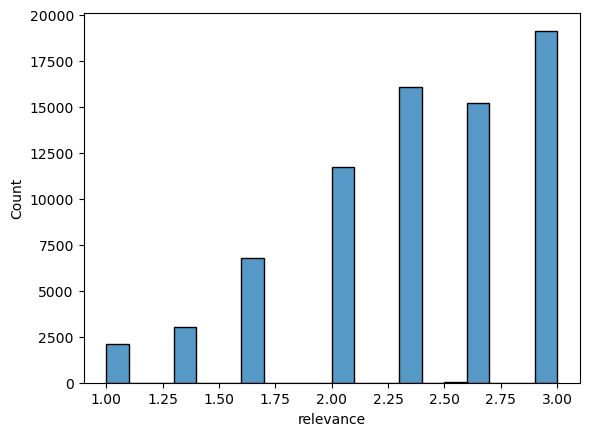

In [16]:
sns.histplot(
    train["relevance"],
    bins=20
)

plt.show()

In [17]:

train["query_length"] = (
    train["search_term"]
    .apply(len)
)

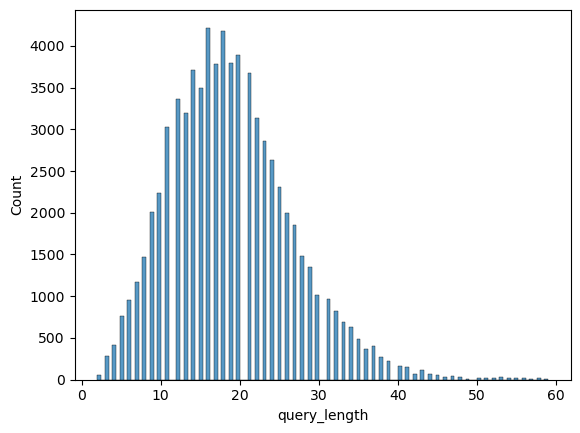

In [18]:
sns.histplot(
    train["query_length"]
)

plt.show()

In [19]:
train["query_length"] = (
    train["search_term"]
    .apply(len)
)

In [20]:
train["title_length"] = (
    train["product_title"]
    .apply(len)
)

In [21]:
def common_words(row):

    query_words = set(
        row["search_term"].split()
    )

    title_words = set(
        row["product_title"].split()
    )

    return len(
        query_words.intersection(
            title_words
        )
    )

In [22]:
train["common_words"] = (
    train.apply(
        common_words,
        axis=1
    )
)

In [23]:
train.head()

,id,product_uid,product_title,search_term,relevance,product_description,query_length,title_length,common_words
0,2,100001,simpson strongtie 12gauge angle,angle bracket,3.00,not only do angles make joints stronger they a...,13,31,1
1,3,100001,simpson strongtie 12gauge angle,l bracket,2.50,not only do angles make joints stronger they a...,9,31,0
2,9,100002,behr premium textured deckover 1gal sc141 tugb...,deck over,3.00,behr premium textured deckover is an innovativ...,9,75,0
3,16,100005,delta vero 1handle shower only faucet trim kit...,rain shower head,2.33,update your bathroom with the delta vero singl...,16,75,1
4,17,100005,delta vero 1handle shower only faucet trim kit...,shower only faucet,2.67,update your bathroom with the delta vero singl...,18,75,3


In [24]:
train.columns

Index(['id', 'product_uid', 'product_title', 'search_term', 'relevance',
       'product_description', 'query_length', 'title_length', 'common_words'],
      dtype='object')

In [25]:
train["combined_text"] = (
    train["search_term"] + " " +
    train["product_title"] + " " +
    train["product_description"]
)

In [26]:
train["combined_text"].head()

0    angle bracket simpson strongtie 12gauge angle ...
1    l bracket simpson strongtie 12gauge angle not ...
2    deck over behr premium textured deckover 1gal ...
3    rain shower head delta vero 1handle shower onl...
4    shower only faucet delta vero 1handle shower o...
Name: combined_text, dtype: object

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [29]:
X_text = tfidf.fit_transform(
    train["combined_text"]
)

In [30]:
X_text.shape

(74067, 5000)

In [31]:
X_text


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4167378 stored elements and shape (74067, 5000)>

In [32]:
numerical_features = train[
    [
        "query_length",
        "title_length",
        "common_words"
    ]
]

In [33]:
numerical_features.head()


,query_length,title_length,common_words
0,13,31,1
1,9,31,0
2,9,75,0
3,16,75,1
4,18,75,3


In [34]:
train["combined_text"] = (
    train["search_term"] + " " +
    train["product_title"] + " " +
    train["product_description"]
)

In [35]:
train["combined_text"].head()


0    angle bracket simpson strongtie 12gauge angle ...
1    l bracket simpson strongtie 12gauge angle not ...
2    deck over behr premium textured deckover 1gal ...
3    rain shower head delta vero 1handle shower onl...
4    shower only faucet delta vero 1handle shower o...
Name: combined_text, dtype: object

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [38]:
max_features=5000

In [39]:
stop_words="english"

In [40]:
X_text = tfidf.fit_transform(
    train["combined_text"]
)

In [41]:
X_text.shape

(74067, 5000)

In [42]:
import scipy.sparse as sp

In [43]:
X = sp.hstack(
    [
        X_text,
        numerical_features
    ]
)

In [44]:
X.shape

(74067, 5003)

In [45]:
y = train["relevance"]

In [46]:
y.head()

0    3.00
1    2.50
2    3.00
3    2.33
4    2.67
Name: relevance, dtype: float64

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.ensemble import RandomForestRegressor

In [50]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(
    X_train,
    y_train
)